# Diversity Metrics for Synthetic EEG

This notebook illustrates three complementary **diversity domains** for evaluating synthetic EEG:

1. **Coverage diversity (manifold coverage)**  
   – Do synthetic samples cover the same regions as real data and avoid unrealistic outliers?

2. **Geometric diversity (PCA / UMAP space)**  
   – Once embedded in a low-dimensional space, do real and synthetic samples share a similar *structure* (cluster position and shape)?

3. **Intrinsic diversity (within-synthetic)**  
   – How diverse are synthetic samples among themselves, compared to real ones (mode collapse vs over-dispersion)?

For each domain we:
- briefly introduce the **metric equations**,
- build simple **2D toy scenarios**,
- and interpret the metric values together with the figures.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from diversity2 import *
import warnings

sns.set(style="white", font_scale=1.2)
plt.rcParams["figure.dpi"] = 120
warnings.filterwarnings("ignore", category=UserWarning)


In [2]:
def plot_real_synth_2d(real, synth, title=""):
    """Simple helper: plot 2D real vs synthetic points."""
    real = np.asarray(real)
    synth = np.asarray(synth)
    df = pd.DataFrame(
        np.vstack([real, synth]),
        columns=["dim1", "dim2"]
    )
    df["Type"] = ["Real"] * len(real) + ["Synthetic"] * len(synth)

    plt.figure(figsize=(5, 4))
    sns.scatterplot(
        data=df, x="dim1", y="dim2", hue="Type",
        palette={"Real": "limegreen", "Synthetic": "lightskyblue"},
        edgecolor="black", s=70, alpha=0.8
    )
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    sns.despine(left=True, bottom=True)
    plt.legend(title="", loc="best")
    plt.tight_layout()
    plt.show()


## 1. Manifold Coverage Diversity

**Goal**  
Assess whether  

- every **real** sample has a nearby **synthetic** neighbour (**coverage**), and  
- every **synthetic** sample lies close to the **real** manifold (**outlier goodness**).

Let  

- ${ \{x_i\}_{i=1}^{N_r} }$ be real samples  
- ${ \{y_j\}_{j=1}^{N_s} }$ be synthetic samples  
- $ d(\cdot, \cdot) $ be the Euclidean distance  


---

### 1.1 Bandwidth

We estimate a data-driven scale from real–real distances:

$$
\sigma = \operatorname{median}\{ d(x_i, x_k) : i \neq k \}.
$$

Define a radius for coverage/outlier tests:

$$
R = k_\sigma \, \sigma,
\qquad k_\sigma \approx 2.
$$

---

### 1.2 Coverage 

For each real point ${x_i}$, the nearest synthetic neighbour is:

$$
d_i^{(r \to s)} = 
\min_{1 \le j \le N_s} d(x_i, y_j).
$$

A real point is considered **covered** if

$$
d_i^{(r \to s)} \le R.
$$

Thus, the coverage score is:

$$
\mathrm{Coverage}
=
\frac{1}{N_r}
\sum_{i=1}^{N_r}
\mathbf{1}\!\left( d_i^{(r \to s)} \le R \right),
\qquad
\mathrm{Coverage} \in [0,1].
$$

---

### 1.3 Outlier goodness 

For each synthetic point ${y_j}$, compute the nearest real neighbour:

$$
d_j^{(s \to r)} =
\min_{1 \le i \le N_r} d(y_j, x_i).
$$

A synthetic point is **non-outlier** if

$$
d_j^{(s \to r)} \le R.
$$

Thus, outlier-goodness is:

$$
\mathrm{Outliers}
=
\frac{1}{N_s}
\sum_{j=1}^{N_s}
\mathbf{1}\!\left( d_j^{(s \to r)} \le R \right),
\qquad
\mathrm{Outliers} \in [0,1].
$$

---

### 1.4 Interpretation

- **Coverage ≈ 1** → every real point is close to some synthetic point  
- **Outliers ≈ 1** → synthetic points remain close to the real manifold  
- Low values indicate:
  - missing modes  
  - synthetic drift  
  - far-out unreal points  


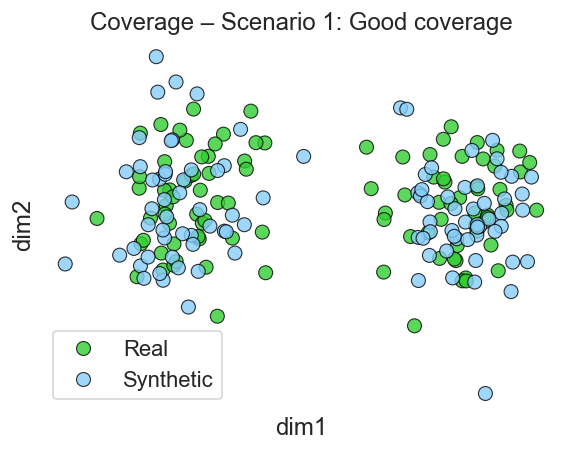

sigma (NN): 0.1575
Radius R = k_sigma * sigma = 0.3150 (k_sigma=2.0)
Coverage (real→synth): 0.850  (↑ better)
Outlier Goodness (synth→real): 0.850  (↑ better)

→ Synthetic data cover both real blobs and stay close to the manifold.


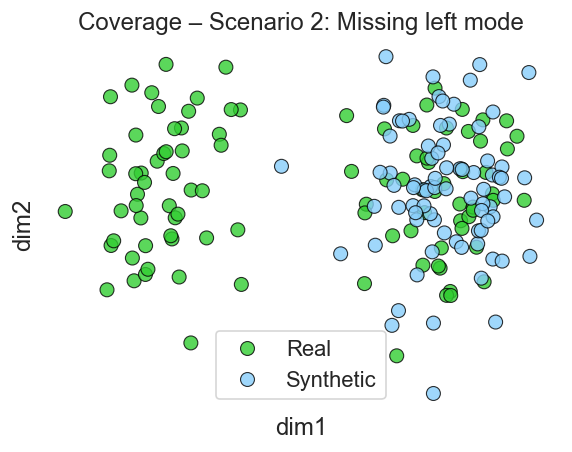

sigma (NN): 0.1575
Radius R = k_sigma * sigma = 0.3150 (k_sigma=2.0)
Coverage (real→synth): 0.440  (↑ better)
Outlier Goodness (synth→real): 0.875  (↑ better)

Coverage ↓ (real points in the missing blob are far from any synthetic neighbour).
Outliers can still be high (synthetic points are always near some real points).
→ Detects mode dropping (real regions with no synthetic coverage).


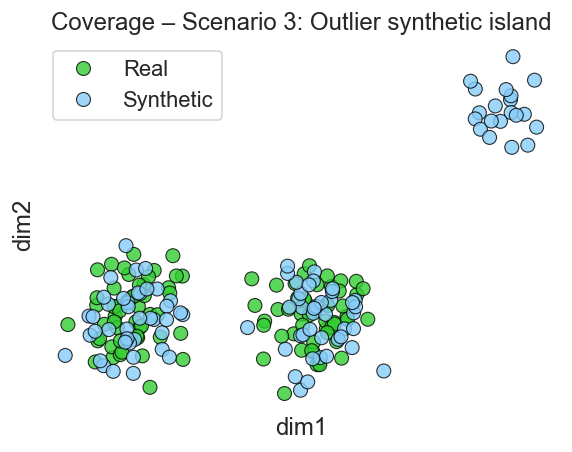

sigma (NN): 0.1575
Radius R = k_sigma * sigma = 0.3150 (k_sigma=2.0)
Coverage (real→synth): 0.840  (↑ better)
Outlier Goodness (synth→real): 0.700  (↑ better)

Coverage remains good around the main blobs.
Outliers ↓ because 20% of synthetic samples are far from all real points.
→ Detects unrealistic synthetic clusters outside the real distribution.


In [4]:
rng = np.random.default_rng(0)
div = Diversity()

# Real data: two blobs (two "modes")
real_blob1 = rng.normal(loc=(-2, 0), scale=0.6, size=(50, 2))
real_blob2 = rng.normal(loc=( 2, 0), scale=0.6, size=(50, 2))
real_cov = np.vstack([real_blob1, real_blob2])

# 1) Good coverage: synthetic follows both blobs
syn_good = np.vstack([
    rng.normal(loc=(-2, 0), scale=0.6, size=(50, 2)),
    rng.normal(loc=( 2, 0), scale=0.6, size=(50, 2)),
])

plot_real_synth_2d(real_cov, syn_good, title="Coverage – Scenario 1: Good coverage")
cov1 = div.compute_coverage_diversity(real_cov, syn_good)
print("")
print("→ Synthetic data cover both real blobs and stay close to the manifold.")

# 2) Missing mode: synthetic covers only right blob
syn_missing = rng.normal(loc=(2, 0), scale=0.6, size=(80, 2))

plot_real_synth_2d(real_cov, syn_missing, title="Coverage – Scenario 2: Missing left mode")
cov2 = div.compute_coverage_diversity(real_cov, syn_missing)
print("")
print("Coverage ↓ (real points in the missing blob are far from any synthetic neighbour).")
print("Outliers can still be high (synthetic points are always near some real points).") 
print("→ Detects mode dropping (real regions with no synthetic coverage).")

# 3) Outlier cluster: good main coverage + far-away synthetic island
syn_outliers_main = np.vstack([
    rng.normal(loc=(-2, 0), scale=0.6, size=(40, 2)),
    rng.normal(loc=( 2, 0), scale=0.6, size=(40, 2)),
])
syn_outlier_island = rng.normal(loc=(6, 4), scale=0.4, size=(20, 2))
syn_outliers = np.vstack([syn_outliers_main, syn_outlier_island])

plot_real_synth_2d(real_cov, syn_outliers, title="Coverage – Scenario 3: Outlier synthetic island")
cov3 = div.compute_coverage_diversity(real_cov, syn_outliers)
print("")
print("Coverage remains good around the main blobs.")
print("Outliers ↓ because 20% of synthetic samples are far from all real points.")
print("→ Detects unrealistic synthetic clusters outside the real distribution.")



## 2. Geometric Diversity in PCA / UMAP Space

**Goal**  
Assess whether real and synthetic data preserve similar **location**, **local mixing**, and **shape** in a shared embedding space (PCA or UMAP).

Let

- ${mu_r}$, ${mu_s}$ be the centroids of real and synthetic embeddings  
- ${S_r}$, ${S_s}$ their covariance matrices  
- ${S_p}$ = ${S_r}$ + ${S_s}$ + ${\epsilon I}$ the pooled covariance  
- labels ${ell_k}$ in {0,1} distinguish real vs. synthetic  


---

## 2.1 Mahalanobis Overlap (centroid alignment)

We measure how close the real and synthetic centroids are, after normalizing by the joint covariance.

The squared Mahalanobis distance is:

$$
d^2
= 
(\mu_r - \mu_s)^\top
S_p^{-1}
(\mu_r - \mu_s).
$$

We convert this to an **overlap score**:

$$
\mathrm{Overlap}
= 
\exp\!\left(
- \frac{1}{2} d^2
\right),
\qquad
\mathrm{Overlap} \in (0, 1].
$$

#### Interpretation

- **Overlap ≈ 1** → centroids aligned; synthetic cloud globally matches the real one  
- **Overlap ≈ 0** → synthetic distribution is shifted (global mismatch)  


---

## 2.2 Label Mixing Score (silhouette-based real ↔ synthetic mixing)

For each embedded point \( k \):

- ${a_k}$: mean distance to samples of the **same** label (real or synthetic)  
- ${b_k}$: mean distance to samples of the **other** label  

The silhouette coefficient is:

$$
s_k
=
\frac{b_k - a_k}{\max(a_k, b_k)},
\qquad s_k \in [-1, 1].
$$

We compute class-wise means and average them:

$$
\bar{s}
=
\frac{
\bar{s}_{\text{real}}
+
\bar{s}_{\text{syn}}
}{2}.
$$

The **Label Mixing Score** is:

$$
\mathrm{LabelMixingScore}
=
1 - |\bar{s}|,
\qquad
\mathrm{LabelMixingScore} \in [0, 1].
$$


#### Interpretation

- **≈ 1** → real and synthetic embed together locally (indistinguishable)  
- **≈ 0.5** → partial mixing  
- **≈ 0** → clearly separated clusters  

This score captures **local interpenetration** rather than global alignment.

---

## 2.3 Covariance Overlap (shape similarity)

We quantify whether real and synthetic embeddings share a similar covariance structure (spread, anisotropy, orientation).

The normalized covariance mismatch is:

$$
D_{\mathrm{cov}}
=
\frac{
\lVert
S_r - S_s
\rVert_F
}{
\lVert S_r \rVert_F + \epsilon
}.
$$

We convert this to a similarity score:

$$
\mathrm{CovarianceOverlap}
=
\exp(-D_{\mathrm{cov}}),
\qquad
\mathrm{CovarianceOverlap} \in (0, 1].
$$


#### Interpretation

- **≈ 1** → synthetic and real distributions share the same shape  
- **Low** → distorted synthetic manifold (elongated, collapsed, rotated…)  

This captures **geometric similarity of the distribution**, independent of centroids.

---



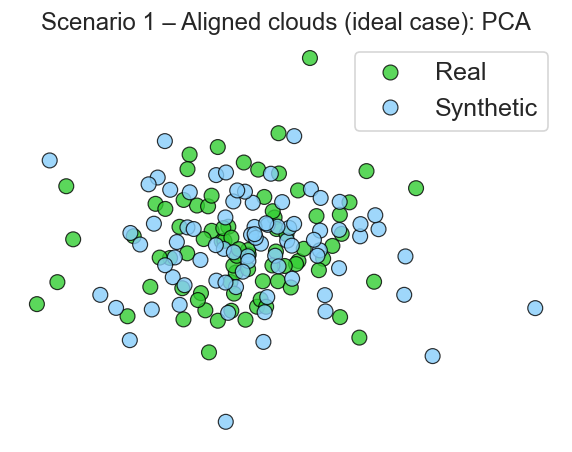

PCA Overlap Mahalanobis: 0.9936159580180789
PCA Label Mixing Score: 0.9957016395120516
PCA Covariance Shape: 0.8529794731280783 

→ Real and synthetic are almost indistinguishable: centroids, label mixing and shape all match.


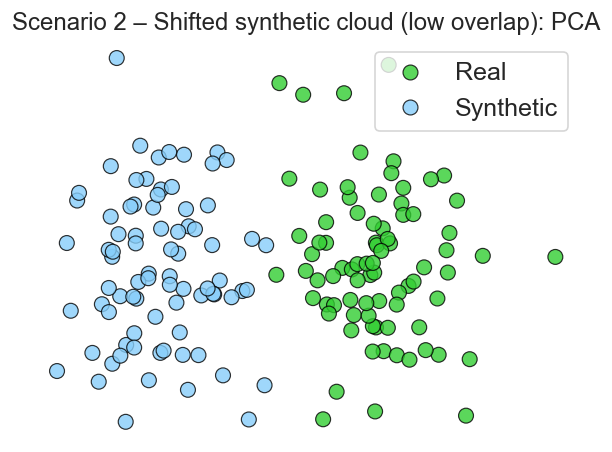

PCA Overlap Mahalanobis: 0.007973184476440989
PCA Label Mixing Score: 0.40682349014094077
PCA Covariance Shape: 0.9302476351736629 

→ Internal shape is similar, but centroids are far apart and labels do not mix (geometric shift).


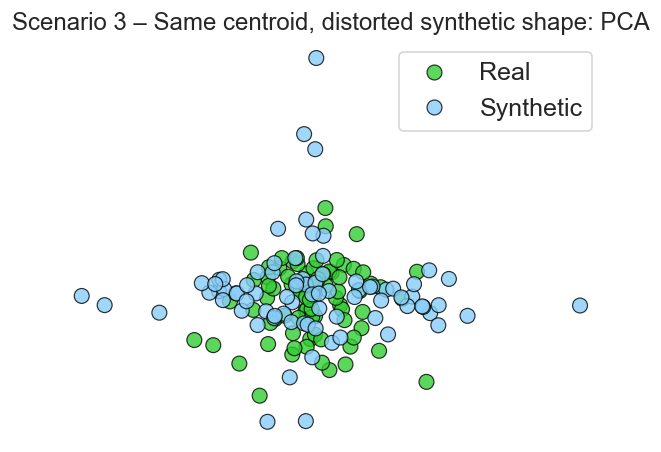

PCA Overlap Mahalanobis: 0.9883298163034439
PCA Label Mixing Score: 0.9673414197970693
PCA Covariance Shape: 0.46813609202519535 

→ Centroids and mixing are reasonable, but covariance shape differs markedly (manifold distorted).


In [3]:
div = Diversity()
rng = np.random.default_rng(1)

def run_geom_example(real, syn, title):
    geom = div.compute_geometric_diversity(real, syn)
    # Show PCA embedding as used by the metric
    div.plot_embeddings("PCA", geom, save=None, plot_title=title)
    #print(title)
    print("PCA Overlap Mahalanobis:", geom["PCA_OverlapMahalanobis"])
    print("PCA Label Mixing Score:", geom["PCA_LabelMixingScore"])
    print("PCA Covariance Shape:", geom["PCA_CovShape"], "\n")
    return geom

# Base real cloud
real_geom = rng.normal(loc=(0, 0), scale=1.0, size=(80, 2))

# 1) Aligned clusters: same mean & covariance
syn_aligned = rng.normal(loc=(0, 0), scale=1.0, size=(80, 2))
geom1 = run_geom_example(real_geom, syn_aligned,
                         "Scenario 1 – Aligned clouds (ideal case): PCA")
print("→ Real and synthetic are almost indistinguishable: centroids, label mixing and shape all match.")

# 2) Shifted synthetic cluster
syn_shifted = rng.normal(loc=(3, 2), scale=1.0, size=(80, 2))
geom2 = run_geom_example(real_geom, syn_shifted,
                         "Scenario 2 – Shifted synthetic cloud (low overlap): PCA")
print("→ Internal shape is similar, but centroids are far apart and labels do not mix (geometric shift).")

# 3) Same centroid, different shape (distorted synthetic manifold)
syn_elong = np.vstack([
    rng.normal(loc=(0, 0), scale=(2.0, 0.3), size=(60, 2)),
    rng.normal(loc=(0, 0), scale=(0.4, 2.0), size=(20, 2)),
])
geom3 = run_geom_example(real_geom, syn_elong,
                         "Scenario 3 – Same centroid, distorted synthetic shape: PCA")
print("→ Centroids and mixing are reasonable, but covariance shape differs markedly (manifold distorted).")


## 3. Intrinsic Diversity – Uniqueness & Local/Global Ratios

Here we compare **within-set distances** in synthetic vs real data.

Let  ${D^{\text{NN}}_{\text{real}}}$ be the vector of nearest-neighbour distances within the real set, and similarly ${ D^{\text{NN}}_{\text{syn}} }$ for the synthetic set.

We compute:

- Mean NN distances:
$$
\bar{d}^{\text{NN}}_{\text{real}} = \mathrm{mean}(D^{\text{NN}}_{\text{real}}),
\quad
\bar{d}^{\text{NN}}_{\text{syn}}   = \mathrm{mean}(D^{\text{NN}}_{\text{syn}})
$$

- Percentiles of NN distances (10th and 50th):
$$
P_{10}^{\text{real}}, P_{50}^{\text{real}}, 
\quad
P_{10}^{\text{syn}}, P_{50}^{\text{syn}}
$$

- Mean pairwise distances (optionally with subsampling):
$$
\bar{d}^{\text{PW}}_{\text{real}}, \quad
\bar{d}^{\text{PW}}_{\text{syn}}
$$

Then the intrinsic diversity metrics are **ratios (synthetic / real)**:

- **Uniqueness** (mean NN distance ratio):
$$
\text{Uniqueness NN} = \frac{\bar{d}^{\text{NN}}_{\text{syn}}}{\bar{d}^{\text{NN}}_{\text{real}}}
$$

- **Global diversity**:
$$
\text{Global Diversity} = 
\frac{\bar{d}^{\text{PW}}_{\text{syn}}}{\bar{d}^{\text{PW}}_{\text{real}}}
$$

- **Local diversity (P10 / P50)**:
$$
\text{Local Diversity P10} = \frac{P_{10}^{\text{syn}}}{P_{10}^{\text{real}}},
\quad
\text{Local Diversity P50} = \frac{P_{50}^{\text{syn}}}{P_{50}^{\text{real}}}
$$

Interpretation:

- $≈$ 1 → synthetic variability matches real variability.  
- $<$ 1 → **mode collapse** (synthetic points too close to each other).  
- $>$ 1 → **over-dispersion** (synthetic points too spread out).


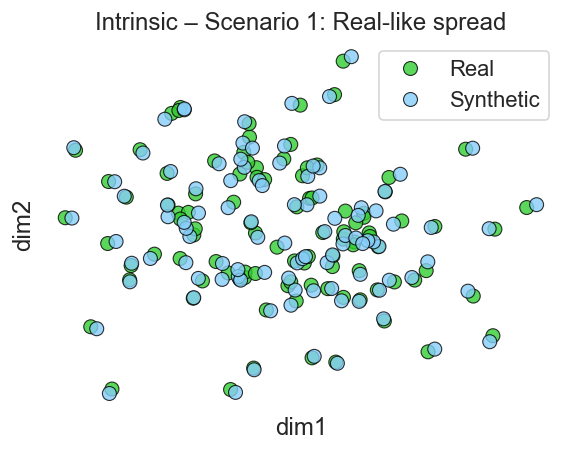

Uniqueness (NN ratio, syn/real): 1.050  (~1 ideal; <1 collapse; >1 over-dispersion)
Global Diversity (pairwise ratio, syn/real): 1.002 (~1 ideal; <1 collapse; >1 over-dispersion)
Local Diversity P10/P50 (NN ratio): 1.146 / 1.118 (~1 ideal; <1 collapse; >1 over-dispersion)

Uniqueness NN ≈ 1; Global Diversity ≈ 1;Local Diversity P10/P50 ≈ 1
→ Synthetic spread is very similar to real: good intrinsic diversity.


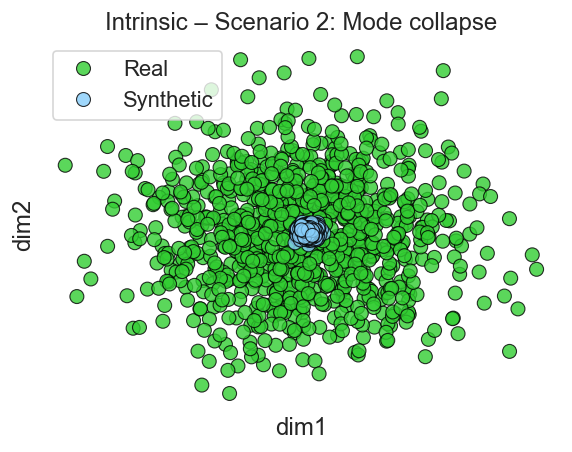

Uniqueness (NN ratio, syn/real): 0.060  (~1 ideal; <1 collapse; >1 over-dispersion)
Global Diversity (pairwise ratio, syn/real): 0.060 (~1 ideal; <1 collapse; >1 over-dispersion)
Local Diversity P10/P50 (NN ratio): 0.054 / 0.059 (~1 ideal; <1 collapse; >1 over-dispersion)

Uniqueness NN < 1 (synthetic NN distances very small); Global Diversity < 1; Local Diversity P10/P50 < 1
→ Strong evidence of mode collapse (many nearly identical samples).


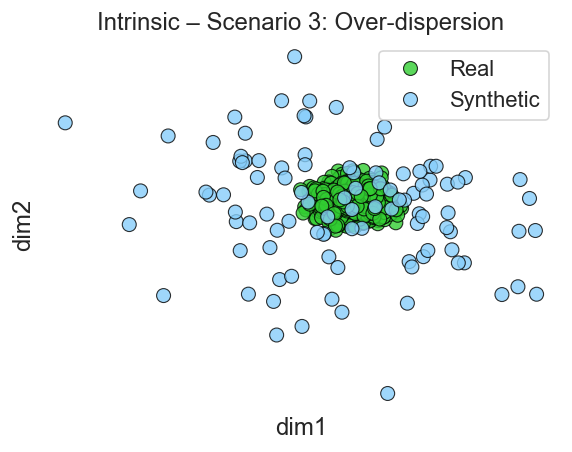

Uniqueness (NN ratio, syn/real): 16.321  (~1 ideal; <1 collapse; >1 over-dispersion)
Global Diversity (pairwise ratio, syn/real): 5.952 (~1 ideal; <1 collapse; >1 over-dispersion)
Local Diversity P10/P50 (NN ratio): 16.197 / 17.489 (~1 ideal; <1 collapse; >1 over-dispersion)

Uniqueness NN > 1; Global Diversity > 1; Local Diversity P10/P50 > 1
→ Synthetic samples are **too spread**, potentially exploring unrealistic regions.


In [3]:
div = Diversity()
rng = np.random.default_rng(2)

# Real baseline cloud
real_intr = rng.normal(loc=(0, 0), scale=1.0, size=(100, 2))

# 1) Real-like synthetic diversity
syn_like = real_intr + rng.normal(0, 0.05, real_intr.shape)
plot_real_synth_2d(real_intr, syn_like, "Intrinsic – Scenario 1: Real-like spread")
intr1 = div.compute_intrinsic_diversity(real_intr, syn_like)
print("")
print("Uniqueness NN ≈ 1; Global Diversity ≈ 1;Local Diversity P10/P50 ≈ 1")
print("→ Synthetic spread is very similar to real: good intrinsic diversity.")

# 2) Mode collapse: synthetic samples highly concentrated
real_intr = rng.normal(loc=(0, 0), scale=0.5, size=(1000, 2))
syn_collapse = rng.normal(loc=(0, 0), scale=0.03, size=(1000, 2))
plot_real_synth_2d(real_intr, syn_collapse, "Intrinsic – Scenario 2: Mode collapse")
intr2 = div.compute_intrinsic_diversity(real_intr, syn_collapse)
print("")
print("Uniqueness NN < 1 (synthetic NN distances very small); Global Diversity < 1; Local Diversity P10/P50 < 1")
print("→ Strong evidence of mode collapse (many nearly identical samples).")

# 3) Over-dispersion: synthetic cloud much more spread
syn_over = rng.normal(0, 3.0, (100, 2))
syn_over += rng.normal(0, 0.5, (100, 2))   # forces local spread too
plot_real_synth_2d(real_intr, syn_over, "Intrinsic – Scenario 3: Over-dispersion")
intr3 = div.compute_intrinsic_diversity(real_intr, syn_over)
print("")
print("Uniqueness NN > 1; Global Diversity > 1; Local Diversity P10/P50 > 1")
print("→ Synthetic samples are **too spread**, potentially exploring unrealistic regions.")


## Summary

- **Coverage diversity (Coverage + Outliers)**  
  Ensures that synthetic EEG signals **reach all regions** of the real distribution while **avoiding unrealistic outliers**.

- **Geometric diversity (Overlap + Compactness)**  
  Evaluates whether real and synthetic data share a similar **geometric structure** in PCA/UMAP space:
  - Overlap → how aligned the centroids are (after normalising by covariance).  
  - Compactness → how cohesive and well-separated the real vs synthetic clusters are (rescaled silhouette).

- **Intrinsic diversity (Uniqueness, Global, Local)**  
  Measures how diverse the synthetic dataset is **by itself**, relative to real:
  - detects **mode collapse** (ratios $<$ 1)  
  - and **over-dispersion** (ratios $>$ 1).

Together, these three domains offer a richer and more interpretable assessment of synthetic EEG diversity than any single metric in isolation.
